In [17]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Skipping, found downloaded files in "./animal-faces" (use force=True to force download)


In [18]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

Device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available, ", Device)

Device Available,  cuda


In [19]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])

print(data_df["labels"].unique())
data_df.head()

['cat' 'wild' 'dog']


,image_path,labels
0,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
1,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
2,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
3,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
4,/content/animal-faces/afhq/train/cat/flickr_ca...,cat


In [20]:
train = data_df.sample(frac = 0.7)
test = data_df.drop(train.index)

val = test.sample(frac = 0.5)
test = test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

(11291, 2)
(2420, 2)
(2419, 2)


In [21]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

transform = transforms.Compose([
    transforms.Resize((128, 128)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),


    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)

])


In [22]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(Device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, index):
    img_path = self.dataframe.iloc[index, 0]
    label = self.labels[index]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(Device)

    return image, label

In [23]:
train_dataset = CustomImageDataset(dataframe = train, transform = transform)
test_dataset = CustomImageDataset(dataframe = test, transform = transform)
val_dataset = CustomImageDataset(dataframe = val, transform = transform)

In [24]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [25]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)

In [26]:
class Net2(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1)
    self.conv4 = nn.Conv2d(128, 256, kernel_size = 3, padding = 1)
    self.pooling = nn.MaxPool2d(2, 2)

    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear = nn.Linear((256 * 8 * 8), 256)
    self.output = nn.Linear(256, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv3(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv4(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x



In [27]:
class Net(nn.Module):
  def __init__(self):

    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1)

    self.pooling = nn.MaxPool2d(2, 2)

    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128 * 16 * 16), 128)

    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv3(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x

In [28]:
model = Net().to(Device)

In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [30]:
total_train_loss = []
total_val_loss = []
total_train_acc = []
total_val_acc = []

Epochs = 10

for epoch in range(Epochs) :
  train_loss = 0
  val_loss = 0
  train_acc = 0
  val_acc = 0

  for inputs, labels in train_loader :
    model.train()
    inputs, labels = inputs.to(Device), labels.to(Device)
    y_pred = model(inputs)
    loss = criterion(y_pred, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    train_acc += (y_pred.argmax(1) == labels).type(torch.float).sum().item()

  model.eval()

  with torch.inference_mode():
    for inputs, labels in val_loader :
      inputs, labels = inputs.to(Device), labels.to(Device)
      y_pred = model(inputs)
      loss = criterion(y_pred, labels)
      val_loss += loss.item()
      val_acc += (y_pred.argmax(1) == labels).type(torch.float).sum().item()

  total_train_loss.append(round(train_loss/1000, 4))
  total_val_loss.append(round(val_loss/ 1000, 4))
  total_train_acc.append(round(train_acc / train_dataset.__len__() * 100, 4))
  total_val_acc.append(round(val_acc / val_dataset.__len__() * 100, 4))

  print({epoch},
   {round(train_loss/1000, 4)},
  {round(val_loss/ 1000, 4)},
  {round(train_acc / train_dataset.__len__() * 100, 4)},
   {round(val_acc / val_dataset.__len__() * 100, 4)})

{0} {0.4536} {0.0581} {70.7643} {85.0826}
{1} {0.2466} {0.0449} {86.7505} {88.595}
{2} {0.1844} {0.0379} {90.3906} {89.876}
{3} {0.1594} {0.0339} {91.9316} {91.6529}
{4} {0.1375} {0.0422} {92.835} {89.876}
{5} {0.1271} {0.0292} {93.517} {92.8926}
{6} {0.1113} {0.0299} {94.1192} {92.7273}
{7} {0.1044} {0.0264} {94.6683} {93.595}
{8} {0.0962} {0.0209} {95.1112} {94.7107}
{9} {0.0889} {0.0209} {95.5186} {94.876}


In [31]:
with torch.inference_mode():
  test_loss = 0
  test_acc = 0
  for inputs, labels in test_loader :
    inputs, labels = inputs.to(Device), labels.to(Device)
    y_pred = model(inputs)
    loss = criterion(y_pred, labels)
    test_loss += loss.item()
    acc = (torch.argmax(y_pred, axis = 1) == labels).sum().item()
    test_acc += acc
print({round(test_loss/1000, 4)}, {round(train_acc / train_dataset.__len__() * 100, 4)})

{0.0193} {95.5186}


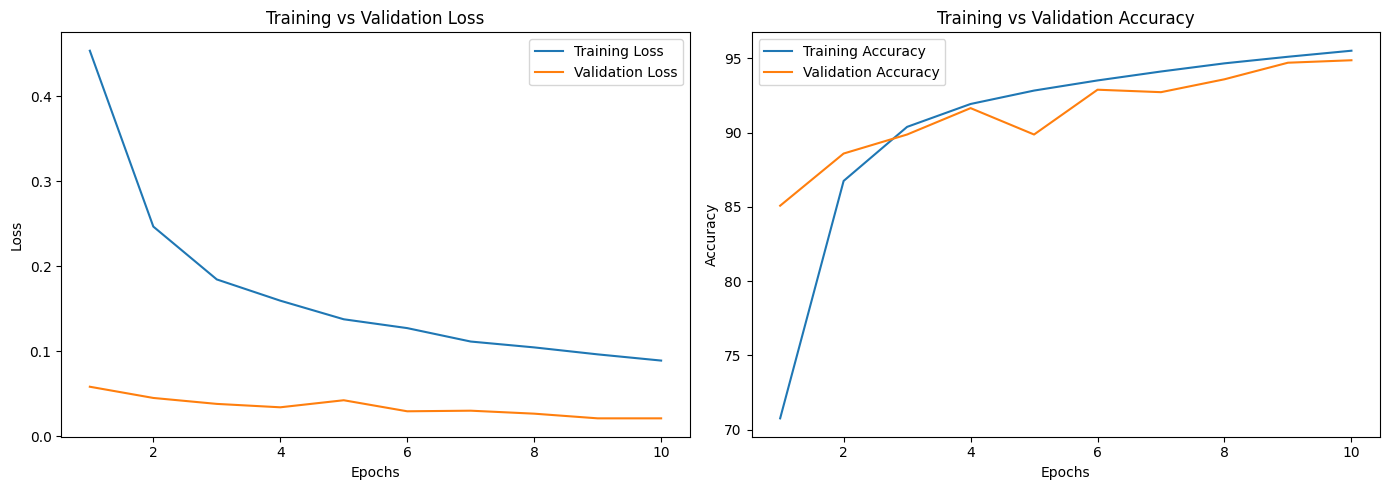

In [32]:
epochs = range(1, len(total_train_loss) + 1)

# Create 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# -------------------
# Loss Plot
# -------------------
ax[0].plot(epochs, total_train_loss, label="Training Loss")
ax[0].plot(epochs, total_val_loss, label="Validation Loss")

ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].legend()

# -------------------
# Accuracy Plot
# -------------------
ax[1].plot(epochs, total_train_acc, label="Training Accuracy")
ax[1].plot(epochs, total_val_acc, label="Validation Accuracy")

ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()